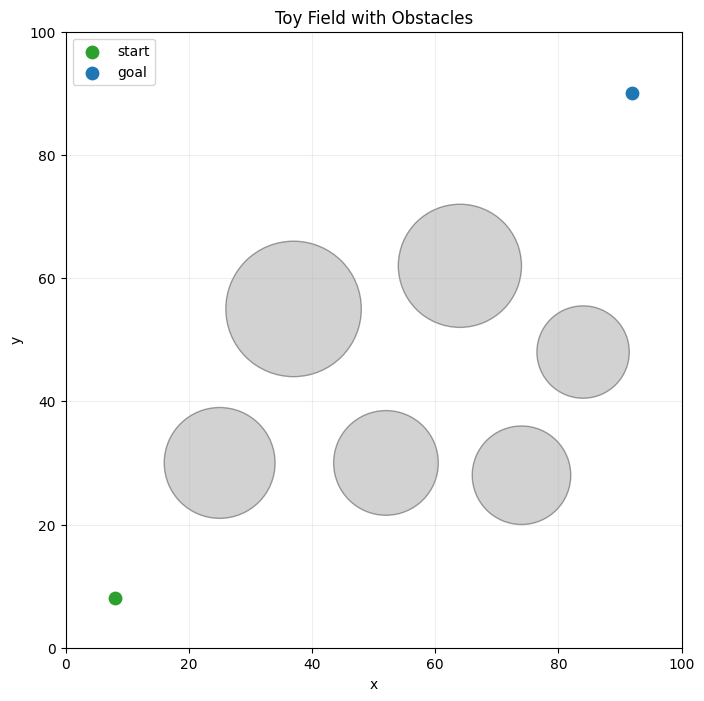

In [1]:
from RRT import RRTPlanner
from FieldClass import ToyFieldClass

bounds = (0.0, 100.0, 0.0, 100.0)
start = (8.0, 8.0)
goal = (92.0, 90.0)

# Fixed circular obstacles for a deterministic toy benchmark.
obstacles = [
    (25.0, 30.0, 9.0),
    (37.0, 55.0, 11.0),
    (52.0, 30.0, 8.5),
    (64.0, 62.0, 10.0),
    (74.0, 28.0, 8.0),
    (84.0, 48.0, 7.5),
]

field = ToyFieldClass(bounds=bounds, obstacles=obstacles, robot_radius=0.6)
field.plot_result(
    nodes=[],
    path=[],
    start=start,
    goal=goal,
    title="Toy Field with Obstacles",
)

Path found with 51 waypoints
Path length: 158.60


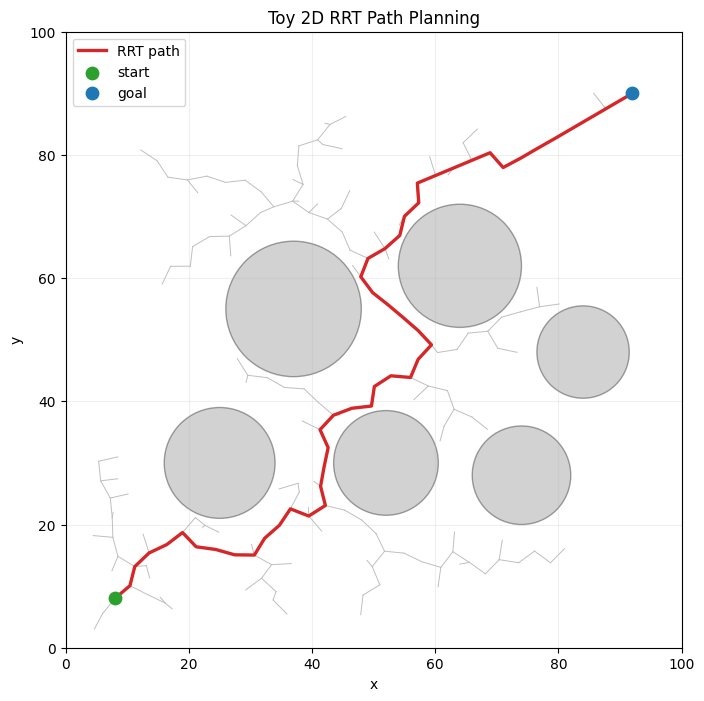

In [2]:
# Create and run the RRT planner
planner = RRTPlanner(
    start=start,
    goal=goal,
    field=field,
    step_size=3.2,
    max_iters=4500,
    goal_bias=0.1,
    goal_tolerance=3.8,
    use_rrt_star=False,
    rrt_star_radius=10.0,
    seed=7,
)
path = planner.plan()
nodes = planner.nodes

if path is None:
    print("No path found. Try increasing max_iters or adjusting obstacles.")
else:
    print(f"Path found with {len(path)} waypoints")
    print(f"Path length: {planner.path_length(path):.2f}")

field.plot_result(
    nodes=nodes,
    path=path,
    start=start,
    goal=goal,
    show=True,
    planner_name="RRT",
)

Path found with 20 waypoints
Path length: 130.94


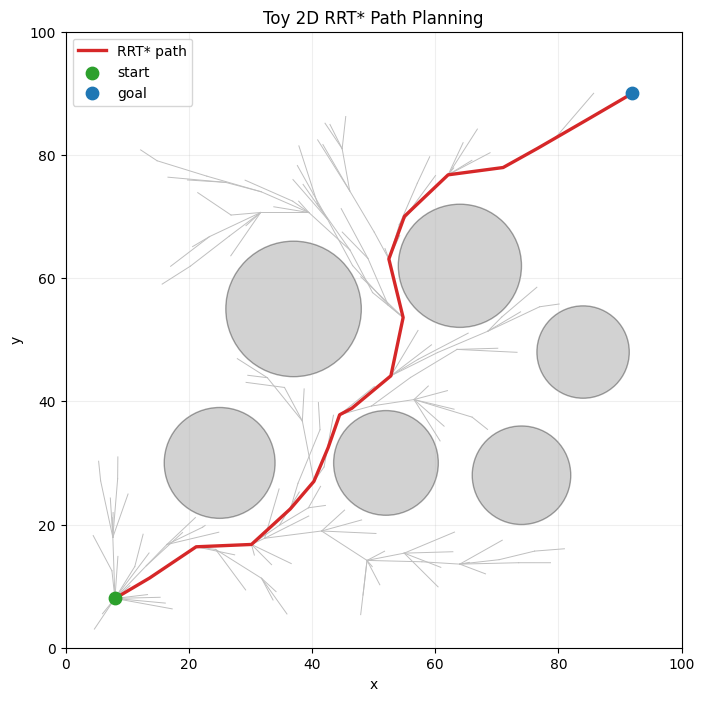

In [3]:
planner = RRTPlanner(
    start=start,
    goal=goal,
    field=field,
    step_size=3.2,
    max_iters=4500,
    goal_bias=0.1,
    goal_tolerance=3.8,
    use_rrt_star=True,
    rrt_star_radius=10.0,
    seed=7,
)
path = planner.plan()
nodes = planner.nodes

if path is None:
    print("No path found. Try increasing max_iters or adjusting obstacles.")
else:
    print(f"Path found with {len(path)} waypoints")
    print(f"Path length: {planner.path_length(path):.2f}")

field.plot_result(
    nodes=nodes,
    path=path,
    start=start,
    goal=goal,
    show=True,
    planner_name="RRT*",
)